## 1 · Setup & Dependencies

In [1]:
# ==============================================================================
# CELL 1 - SETUP & DEPENDENCIES
# ==============================================================================
# Installs yfinance (all other libs ship with Colab). The -q flag keeps output
# clean. Pinning avoids surprise breaking changes in a fresh clone.
# ==============================================================================

!pip install -q --upgrade yfinance

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")

# Global plotting style - a restrained, professional palette
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

RNG = np.random.default_rng(42)  # reproducible Monte Carlo
print("Environment ready.")

Environment ready.


## 2 · Configuration
Change the portfolio here and the whole engine adapts. Weights must sum to 1.0.

In [2]:
# ==============================================================================
# CELL 2 - CONFIGURATION
# ==============================================================================
CONFIG = {
    "tickers":       ["SPY", "TLT", "GLD", "QQQ", "EEM"],  # equity, bonds, gold, tech, EM
    "weights":       np.array([0.35, 0.20, 0.15, 0.20, 0.10]),
    "start_date":    "2015-01-01",
    "end_date":      "2024-12-31",
    "portfolio_value": 1_000_000,               # USD notional
    "confidence_levels": [0.95, 0.99, 0.975],   # 0.975 = FRTB ES level
    "mc_simulations": 50_000,
    "backtest_window": 500,                     # rolling window (~2y trading days)
}

# --- Input validation: fail loudly and early -------------------------------
assert abs(CONFIG["weights"].sum() - 1.0) < 1e-9, "Portfolio weights must sum to 1."
assert len(CONFIG["tickers"]) == len(CONFIG["weights"]), "Tickers/weights length mismatch."
print("Configuration validated.")
print(f"Portfolio: {dict(zip(CONFIG['tickers'], CONFIG['weights']))}")

Configuration validated.
Portfolio: {'SPY': np.float64(0.35), 'TLT': np.float64(0.2), 'GLD': np.float64(0.15), 'QQQ': np.float64(0.2), 'EEM': np.float64(0.1)}


## 3 · Data Collection Pipeline
Fetches adjusted-close prices and builds a single portfolio return series.

# Portfolio Risk Engine — Value-at-Risk & Expected Shortfall

**A regulatory-grade tail-risk system with statistical backtesting.**

This notebook computes 1-day Value-at-Risk (VaR) and Expected Shortfall (ES) for a
multi-asset portfolio using three independent methodologies — Historical Simulation,
Parametric (Gaussian & Student-t), and Monte Carlo — then validates them with the
Kupiec and Christoffersen backtests used in bank risk management under Basel/FRTB.

**How to run:** `Runtime → Run all`. No API keys required (data comes from Yahoo Finance).

---


In [3]:
# ==============================================================================
# CELL 3 - DATA COLLECTION PIPELINE
# ==============================================================================
# Adjusted close accounts for dividends/splits - essential for correct returns.
# Wrapped in error handling because network/data issues are the #1 cause of
# broken finance notebooks.
# ==============================================================================

def fetch_prices(tickers, start, end):
    """Download adjusted-close prices. Returns a clean, aligned DataFrame."""
    try:
        raw = yf.download(tickers, start=start, end=end,
                          auto_adjust=True, progress=False)
        if raw.empty:
            raise ValueError("yfinance returned no data - check tickers/dates.")
        # Handle both multi-index and single-index frames
        if isinstance(raw.columns, pd.MultiIndex):
            prices = raw["Close"]
        else:
            prices = raw[["Close"]]
        prices = prices.dropna(how="all").ffill().dropna()
        if prices.shape[0] < CONFIG["backtest_window"] + 50:
            raise ValueError("Insufficient history for the requested backtest window.")
        return prices
    except Exception as e:
        raise RuntimeError(f"Data fetch failed: {e}")

prices = fetch_prices(CONFIG["tickers"], CONFIG["start_date"], CONFIG["end_date"])
prices = prices[CONFIG["tickers"]]  # enforce column order to match weights

# Daily arithmetic returns (appropriate for weight-based portfolio aggregation)
asset_returns = prices.pct_change().dropna()
portfolio_returns = asset_returns @ CONFIG["weights"]
portfolio_returns.name = "portfolio"

print(f"Loaded {prices.shape[0]} trading days across {prices.shape[1]} assets.")
print(f"Date range: {prices.index[0].date()} -> {prices.index[-1].date()}")
print(f"Annualized portfolio vol:    {portfolio_returns.std() * np.sqrt(252):.2%}")
print(f"Annualized portfolio return: {portfolio_returns.mean() * 252:.2%}")

Loaded 2515 trading days across 5 assets.
Date range: 2015-01-02 -> 2024-12-30
Annualized portfolio vol:    12.31%
Annualized portfolio return: 10.49%


## 4 · VaR & ES Estimators (Core Models)
Three independent methodologies. All outputs are **positive loss fractions** (0.021 = a 2.1% loss).

In [4]:
# ==============================================================================
# CELL 4 - VaR & ES ESTIMATORS (CORE MODELS)
# ==============================================================================

def historical_var_es(returns, alpha):
    """Historical Simulation: empirical quantile of losses; ES = mean beyond VaR.
    Strength: captures real fat tails/skew. Weakness: bounded by observed past."""
    losses = -np.asarray(returns)
    var = np.quantile(losses, alpha)
    es = losses[losses >= var].mean()
    return var, es

def parametric_var_es(returns, alpha, dist="normal"):
    """Parametric (Variance-Covariance). 'normal' = Gaussian; 'student_t' fits
    fatter tails - usually a better real-world fit for daily returns."""
    mu, sigma = np.mean(returns), np.std(returns, ddof=1)
    if dist == "normal":
        z = stats.norm.ppf(alpha)
        var = -(mu - sigma * z)
        es = -(mu - sigma * stats.norm.pdf(z) / (1 - alpha))
    elif dist == "student_t":
        nu, loc, scale = stats.t.fit(returns)      # fit degrees of freedom
        t_q = stats.t.ppf(alpha, nu)
        var = -(loc - scale * t_q)
        es_factor = (nu + t_q**2) / (nu - 1) * stats.t.pdf(t_q, nu) / (1 - alpha)
        es = -(loc - scale * es_factor)
    else:
        raise ValueError("dist must be 'normal' or 'student_t'")
    return var, es

def monte_carlo_var_es(returns, alpha, n_sims):
    """Monte Carlo: simulate from a fitted distribution, then read off the tail.
    Framework generalizes to full multi-asset covariance simulation."""
    mu, sigma = np.mean(returns), np.std(returns, ddof=1)
    sims = RNG.normal(mu, sigma, n_sims)
    losses = -sims
    var = np.quantile(losses, alpha)
    es = losses[losses >= var].mean()
    return var, es

# --- Build a full comparison table at each confidence level ----------------
records = []
pv = CONFIG["portfolio_value"]
for cl in CONFIG["confidence_levels"]:
    h_var, h_es = historical_var_es(portfolio_returns, cl)
    n_var, n_es = parametric_var_es(portfolio_returns, cl, "normal")
    t_var, t_es = parametric_var_es(portfolio_returns, cl, "student_t")
    m_var, m_es = monte_carlo_var_es(portfolio_returns, cl, CONFIG["mc_simulations"])
    for name, (v, e) in {
        "Historical":   (h_var, h_es),
        "Parametric-N": (n_var, n_es),
        "Parametric-t": (t_var, t_es),
        "MonteCarlo":   (m_var, m_es),
    }.items():
        records.append({"Confidence": f"{cl:.1%}", "Method": name,
                        "VaR_%": v, "ES_%": e, "VaR_$": v*pv, "ES_$": e*pv})

results = pd.DataFrame(records)
summary = results.pivot_table(index="Method", columns="Confidence", values="VaR_$").round(0)
print("1-Day VaR ($) by method and confidence level:\n")
print(summary.to_string())

1-Day VaR ($) by method and confidence level:

Confidence      95.0%    97.5%    99.0%
Method                                 
Historical    11523.0  15800.0  21030.0
MonteCarlo    12368.0  14805.0  17834.0
Parametric-N  12334.0  14777.0  17617.0
Parametric-t  10833.0  14616.0  20590.0


## 5 · Backtesting Layer (Kupiec + Christoffersen)

The heart of the project. We roll a 500-day window, forecast next-day VaR, and record breaches.

- **Kupiec POF** — is the *number* of breaches statistically correct?
- **Christoffersen** — are breaches *independent*, or do they cluster in crises?

`p > 0.05` on both → the model is well-calibrated.

In [5]:
# ==============================================================================
# CELL 5 - BACKTESTING LAYER (Kupiec + Christoffersen)
# ==============================================================================

def rolling_var_backtest(returns, alpha, window, method="historical"):
    """Walk forward: estimate VaR on trailing window, test against next return."""
    returns = np.asarray(returns)
    n = len(returns)
    var_forecasts, realized, exceptions = [], [], []
    for t in range(window, n):
        train = returns[t - window:t]
        if method == "historical":
            var, _ = historical_var_es(train, alpha)
        elif method == "parametric":
            var, _ = parametric_var_es(train, alpha, "normal")
        else:
            raise ValueError("method must be 'historical' or 'parametric'")
        var_forecasts.append(var)
        realized.append(returns[t])
        exceptions.append(int(-returns[t] > var))
    return np.array(var_forecasts), np.array(realized), np.array(exceptions)

def kupiec_pof(exceptions, alpha):
    """Kupiec Proportion-of-Failures LR test. H0: coverage is correct."""
    n = len(exceptions); x = int(exceptions.sum()); p = 1 - alpha
    pi = x / n if n else 0
    if x == 0 or x == n:                       # degenerate guard
        return np.nan, np.nan, x, n * p
    lr = -2 * ((n - x)*np.log(1 - p) + x*np.log(p)
               - (n - x)*np.log(1 - pi) - x*np.log(pi))
    return lr, 1 - stats.chi2.cdf(lr, df=1), x, n * p

def christoffersen_independence(exceptions):
    """Tests whether an exception today predicts one tomorrow (clustering)."""
    e = np.asarray(exceptions)
    n00 = np.sum((e[:-1]==0)&(e[1:]==0)); n01 = np.sum((e[:-1]==0)&(e[1:]==1))
    n10 = np.sum((e[:-1]==1)&(e[1:]==0)); n11 = np.sum((e[:-1]==1)&(e[1:]==1))
    if (n00+n01)==0 or (n10+n11)==0 or (n01+n11)==0:
        return np.nan, np.nan
    pi01 = n01/(n00+n01); pi11 = n11/(n10+n11); pi = (n01+n11)/(n00+n01+n10+n11)
    num = (1-pi)**(n00+n10) * pi**(n01+n11)
    den = (1-pi01)**n00 * pi01**n01 * (1-pi11)**n10 * pi11**n11
    lr = -2*np.log(num/den) if den > 0 else np.nan
    return lr, 1 - stats.chi2.cdf(lr, df=1)

# --- Run backtest at 99% (the classic Basel level) -------------------------
BT_ALPHA = 0.99
bt_results = {}
for method in ["historical", "parametric"]:
    vf, rz, ex = rolling_var_backtest(portfolio_returns, BT_ALPHA,
                                      CONFIG["backtest_window"], method)
    lr_k, p_k, obs_exc, exp_exc = kupiec_pof(ex, BT_ALPHA)
    lr_c, p_c = christoffersen_independence(ex)
    bt_results[method] = {"var": vf, "realized": rz, "exceptions": ex,
                          "obs_exceptions": obs_exc, "exp_exceptions": exp_exc,
                          "kupiec_p": p_k, "christoffersen_p": p_c}

print(f"BACKTEST RESULTS @ {BT_ALPHA:.0%} confidence "
      f"({len(bt_results['historical']['exceptions'])} test days)\n")
for m, r in bt_results.items():
    verdict = "PASS" if (r["kupiec_p"] > 0.05 and r["christoffersen_p"] > 0.05) else "REVIEW"
    print(f"  {m.capitalize():12s} | Exceptions: {r['obs_exceptions']:.0f} "
          f"(expected {r['exp_exceptions']:.1f}) | Kupiec p={r['kupiec_p']:.3f} | "
          f"Christoffersen p={r['christoffersen_p']:.3f} | {verdict}")
print("\np > 0.05 -> fail to reject H0 -> model is well-calibrated.")

BACKTEST RESULTS @ 99% confidence (2014 test days)

  Historical   | Exceptions: 23 (expected 20.1) | Kupiec p=0.531 | Christoffersen p=0.002 | REVIEW
  Parametric   | Exceptions: 49 (expected 20.1) | Kupiec p=0.000 | Christoffersen p=0.007 | REVIEW

p > 0.05 -> fail to reject H0 -> model is well-calibrated.


## 6 · Visualization 1 — Method Comparison

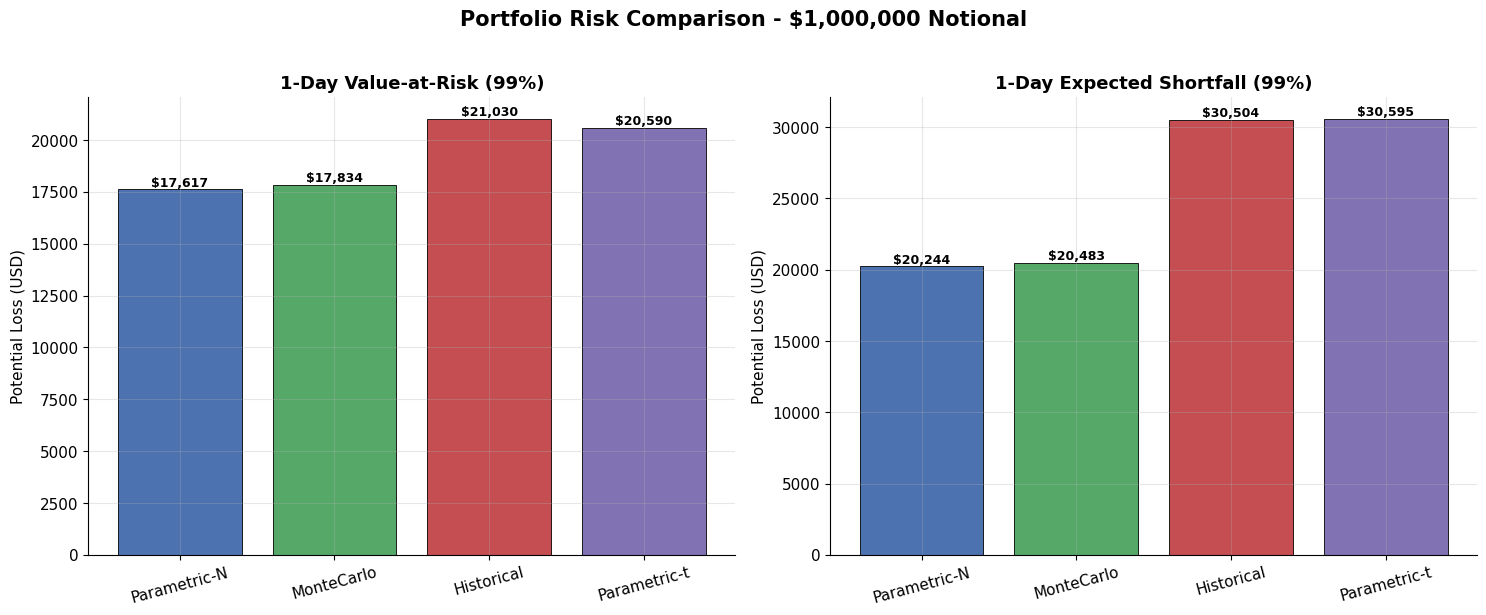

In [6]:
# ==============================================================================
# CELL 6 - VISUALIZATION 1: METHOD COMPARISON
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sub = results[results["Confidence"] == "99.0%"].set_index("Method")
order = ["Parametric-N", "MonteCarlo", "Historical", "Parametric-t"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3"]

for ax, metric, title in zip(axes, ["VaR_$", "ES_$"],
                             ["Value-at-Risk (99%)", "Expected Shortfall (99%)"]):
    vals = sub.loc[order, metric]
    bars = ax.bar(order, vals, color=colors, edgecolor="black", linewidth=0.6)
    ax.set_title(f"1-Day {title}")
    ax.set_ylabel("Potential Loss (USD)")
    ax.tick_params(axis="x", rotation=15)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v, f"${v:,.0f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

fig.suptitle(f"Portfolio Risk Comparison - ${pv:,.0f} Notional",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 · Visualization 2 — Return Distribution with Risk Cutoffs
The signature chart for your README.

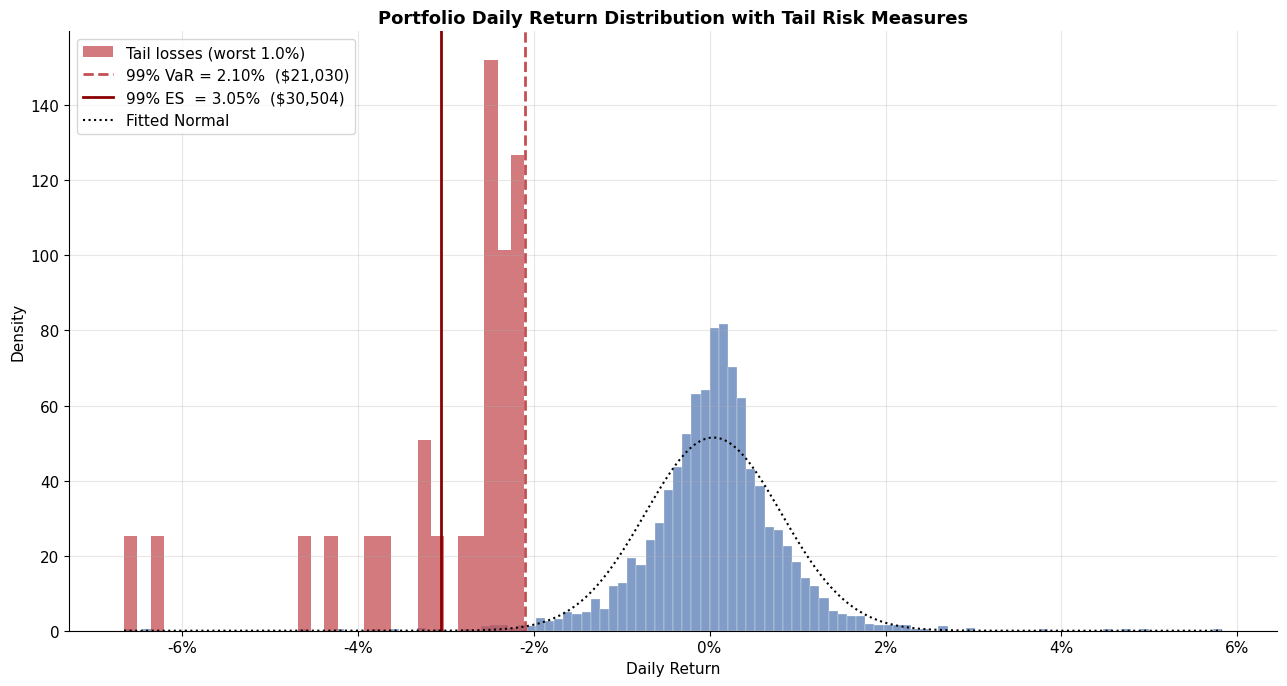

In [7]:
# ==============================================================================
# CELL 7 - VISUALIZATION 2: RETURN DISTRIBUTION WITH RISK CUTOFFS
# ==============================================================================
fig, ax = plt.subplots(figsize=(13, 7))
rets = portfolio_returns.values
h_var, h_es = historical_var_es(portfolio_returns, 0.99)

ax.hist(rets, bins=120, color="#4C72B0", alpha=0.7, edgecolor="white",
        linewidth=0.3, density=True)
tail = rets[rets <= -h_var]
ax.hist(tail, bins=30, color="#C44E52", alpha=0.75, density=True,
        label=f"Tail losses (worst {(len(tail)/len(rets)):.1%})")
ax.axvline(-h_var, color="#C44E52", ls="--", lw=2,
           label=f"99% VaR = {h_var:.2%}  (${h_var*pv:,.0f})")
ax.axvline(-h_es, color="darkred", ls="-", lw=2,
           label=f"99% ES  = {h_es:.2%}  (${h_es*pv:,.0f})")
x = np.linspace(rets.min(), rets.max(), 500)
ax.plot(x, stats.norm.pdf(x, rets.mean(), rets.std()), color="black", lw=1.5,
        ls=":", label="Fitted Normal")

ax.set_title("Portfolio Daily Return Distribution with Tail Risk Measures")
ax.set_xlabel("Daily Return"); ax.set_ylabel("Density")
ax.legend(frameon=True, loc="upper left")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.savefig("return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 · Visualization 3 — Rolling Backtest with Exception Markers
The validation chart a risk interviewer wants to see.

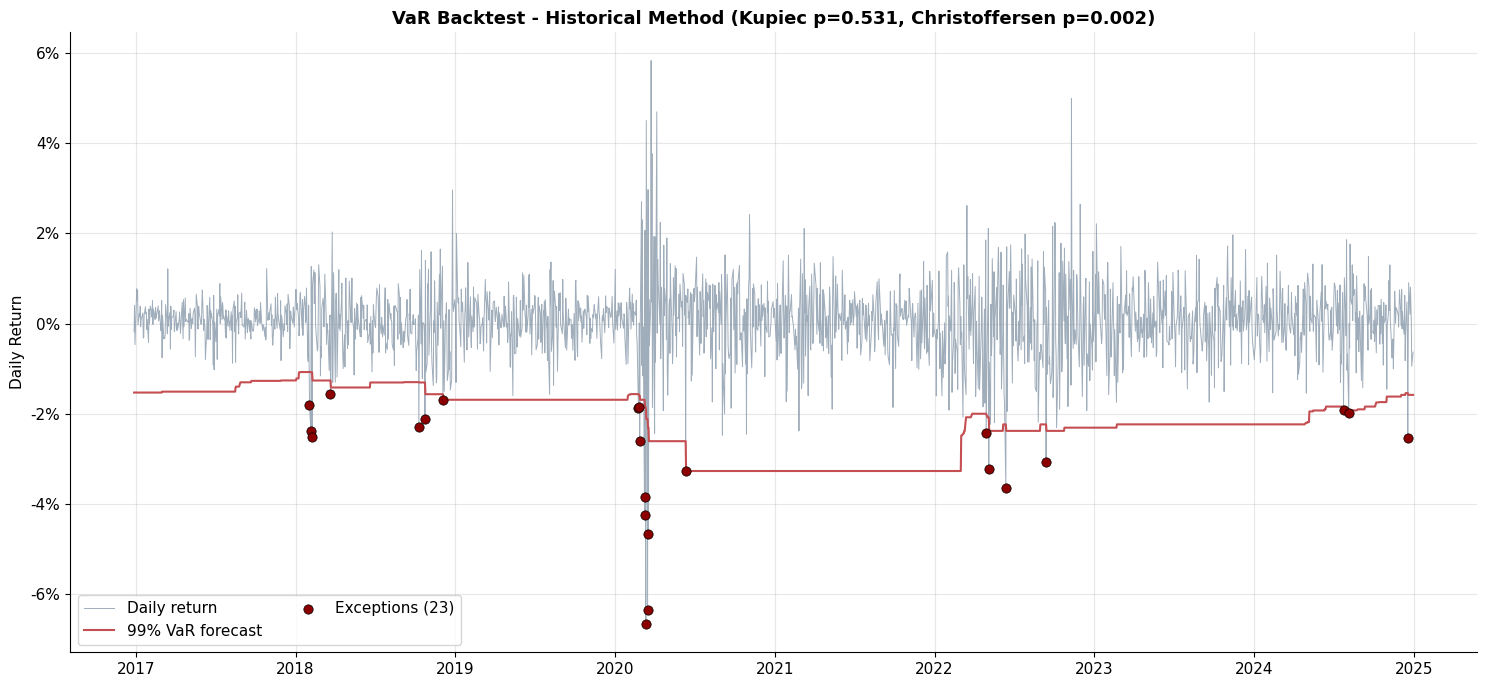


23 breaches vs 20.1 expected. Breaches cluster in stress periods - consider EWMA/GARCH vol.


In [8]:
# ==============================================================================
# CELL 8 - VISUALIZATION 3: ROLLING BACKTEST WITH EXCEPTION MARKERS
# ==============================================================================
method_to_plot = "historical"
r = bt_results[method_to_plot]
dates = portfolio_returns.index[CONFIG["backtest_window"]:]

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(dates, r["realized"], color="#8899AA", lw=0.7, alpha=0.8, label="Daily return")
ax.plot(dates, -r["var"], color="#C44E52", lw=1.5, label=f"{BT_ALPHA:.0%} VaR forecast")
exc_mask = r["exceptions"].astype(bool)
ax.scatter(dates[exc_mask], r["realized"][exc_mask], color="darkred", s=45, zorder=5,
           edgecolor="black", linewidth=0.5, label=f"Exceptions ({exc_mask.sum()})")

ax.set_title(f"VaR Backtest - {method_to_plot.capitalize()} Method "
             f"(Kupiec p={r['kupiec_p']:.3f}, Christoffersen p={r['christoffersen_p']:.3f})")
ax.set_ylabel("Daily Return")
ax.legend(frameon=True, loc="lower left", ncol=2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig("backtest_exceptions.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{exc_mask.sum()} breaches vs {r['exp_exceptions']:.1f} expected. " +
      ("Breaches cluster in stress periods - consider EWMA/GARCH vol."
       if r['christoffersen_p'] < 0.05 else "Breaches are well-dispersed across time."))

## 9 · Final Risk Report

In [9]:
# ==============================================================================
# CELL 9 - FINAL RISK REPORT (TEXT SUMMARY)
# ==============================================================================
print("=" * 70)
print("           PORTFOLIO RISK REPORT - 1-DAY HORIZON")
print("=" * 70)
print(f"Notional: ${pv:,.0f}   |   Assets: {', '.join(CONFIG['tickers'])}")
print(f"Period:   {prices.index[0].date()} -> {prices.index[-1].date()}")
print("-" * 70)
print(f"{'Method':<16}{'95% VaR':>12}{'99% VaR':>12}{'97.5% ES':>12}")
print("-" * 70)
for method in ["Historical", "Parametric-N", "Parametric-t", "MonteCarlo"]:
    v95  = results[(results.Method==method)&(results.Confidence=="95.0%")]["VaR_$"].values[0]
    v99  = results[(results.Method==method)&(results.Confidence=="99.0%")]["VaR_$"].values[0]
    es975= results[(results.Method==method)&(results.Confidence=="97.5%")]["ES_$"].values[0]
    print(f"{method:<16}{'$'+format(v95,',.0f'):>12}{'$'+format(v99,',.0f'):>12}{'$'+format(es975,',.0f'):>12}")
print("-" * 70)
print("Backtest verdict @ 99%:")
for m, r in bt_results.items():
    ok = r["kupiec_p"] > 0.05 and r["christoffersen_p"] > 0.05
    print(f"  {m.capitalize():<12} {'[OK] well-calibrated' if ok else '[!] review model'}")
print("=" * 70)
print("Note: 97.5% ES is the FRTB-mandated regulatory risk measure.")

# Optional: download charts from Colab to your machine
# from google.colab import files
# for f in ["method_comparison.png","return_distribution.png","backtest_exceptions.png"]:
#     files.download(f)

           PORTFOLIO RISK REPORT - 1-DAY HORIZON
Notional: $1,000,000   |   Assets: SPY, TLT, GLD, QQQ, EEM
Period:   2015-01-02 -> 2024-12-30
----------------------------------------------------------------------
Method               95% VaR     99% VaR    97.5% ES
----------------------------------------------------------------------
Historical           $11,523     $21,030     $23,153
Parametric-N         $12,334     $17,617     $17,706
Parametric-t         $10,833     $20,590     $22,466
MonteCarlo           $12,368     $17,834     $17,729
----------------------------------------------------------------------
Backtest verdict @ 99%:
  Historical   [!] review model
  Parametric   [!] review model
Note: 97.5% ES is the FRTB-mandated regulatory risk measure.
